In [ ]:
# -*- coding: utf-8 -*-
"""vpr_dinov2_v4_FINAL.ipynb"""

# ============================================================
# Hücre 1: Kütüphane Kurulumu
# ============================================================
!pip install faiss-cpu folium pytorch-metric-learning scikit-learn -q
print("✅ Tüm kütüphaneler kuruldu (Metric Learning dahil).")

# ============================================================
# Hücre 2: Import'lar ve Konfigürasyon
# ============================================================
import os, json, random, zipfile, shutil, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from pytorch_metric_learning import losses, miners
from pytorch_metric_learning.samplers import MPerClassSampler
from sklearn.preprocessing import LabelEncoder

import faiss
import folium

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# ─── Konfigürasyon ──────────────────────────────────────────
DRIVE_ZIP     = "/content/drive/My Drive/kirsehir_data.zip"
LOCAL_ROOT    = "/content/kirsehir_data"
OUTPUT_DIR    = "/content/drive/My Drive/Kirsehir_VPR_DINOv2_v4_Final"

MODEL_NAME    = "dinov2_vitb14"
OUTFEATURES   = 512
# DINOv2 için patch size 14'ün katı olmalı (518 optimumdur, 644 OOM hatası verebilir)
IMG_SIZE      = 518
BATCH_SIZE    = 32
EPOCHS        = 5
NUM_WORKERS   = 2

TOP_K         = 10
FINAL_K       = 5
GPS_THRESHOLDS = [25, 50, 100]
GRID_SIZE     = 0.002

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Yapılandırma Tamam. Cihaz: {DEVICE} - Model: {MODEL_NAME}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 147.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.8/127.8 kB 16.4 MB/s eta 0:00:00
✅ Tüm kütüphaneler kuruldu (Metric Learning dahil).
✅ Yapılandırma Tamam. Cihaz: cuda - Model: dinov2_vitb14


In [ ]:
# ============================================================
# Hücre 3: Veri Yükleme ve DOĞRU VERİ BÖLME (Split) Mantığı
# ============================================================
from google.colab import drive
drive.mount("/content/drive")
os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.exists(LOCAL_ROOT):
    LOCAL_ZIP = "/content/kirsehir_data.zip"
    shutil.copy2(DRIVE_ZIP, LOCAL_ZIP)
    with zipfile.ZipFile(LOCAL_ZIP, 'r') as zf:
        zf.extractall(LOCAL_ROOT)
    os.remove(LOCAL_ZIP)

entries = os.listdir(LOCAL_ROOT)
if len(entries) == 1 and os.path.isdir(os.path.join(LOCAL_ROOT, entries[0])):
    LOCAL_ROOT = os.path.join(LOCAL_ROOT, entries[0])

def extract_lat_lon_heading(filepath):
    basename = os.path.basename(filepath)
    name_no_ext = os.path.splitext(basename)[0]
    parts = name_no_ext.split("_")
    try:
        return float(parts[0]), float(parts[1]), float(parts[2].replace("h", "") if len(parts)>2 else "0")
    except: return None, None, None

all_images =[]
for street_name in sorted(os.listdir(LOCAL_ROOT)):
    street_path = os.path.join(LOCAL_ROOT, street_name)
    if not os.path.isdir(street_path) or street_name == "model": continue
    for fname in sorted(os.listdir(street_path)):
        if not fname.lower().endswith((".jpg", ".jpeg", ".png")): continue
        fpath = os.path.join(street_path, fname)
        lat, lon, heading = extract_lat_lon_heading(fpath)
        if lat is not None:
            all_images.append({
                "filepath": fpath, "street": street_name,
                "lat": lat, "lon": lon, "heading": heading,
                "point_id": f"{lat:.6f}_{lon:.6f}",
                "block_id": f"{int(lat/GRID_SIZE)}_{int(lon/GRID_SIZE)}"
            })

df_all = pd.DataFrame(all_images)
df_all = df_all.sort_values(by=["point_id", "heading"])

# ─── 1. Adım: Şehri Train ve Test olarak bloklara böl ───
unique_blocks = df_all["block_id"].unique().tolist()
random.shuffle(unique_blocks)
n_blocks = len(unique_blocks)

train_blocks = set(unique_blocks[:int(n_blocks * 0.70)])
test_blocks  = set(unique_blocks[int(n_blocks * 0.70):])

# ─── 2. Adım: Metric Learning Eğitimi İçin Veri Hazırlığı ───
df_train = df_all[df_all["block_id"].isin(train_blocks)].copy()
# DİKKAT: Sınıf olarak Yönü (heading) değil, Sokağı (point_id) veriyoruz!
df_train["class_id"] = df_train["point_id"]
le = LabelEncoder()
df_train["label"] = le.fit_transform(df_train["class_id"])

# ─── 3. Adım: Gerçekçi VPR Testi İçin Query/DB Bölünmesi ───
df_test = df_all[df_all["block_id"].isin(test_blocks)].copy()

# Sadece en az 2 fotoğrafı olan noktaları testte kullanalım
point_counts = df_test['point_id'].value_counts()
valid_points = point_counts[point_counts >= 2].index
df_test = df_test[df_test['point_id'].isin(valid_points)]

# Her noktanın SON çekilen yönünü Query (Sorgu) yapıyoruz.
df_query = df_test.groupby("point_id").tail(1).reset_index(drop=True)
query_filepaths = set(df_query["filepath"])

# Kalan tüm yönleri DB (Harita/Veritabanı) yapıyoruz.
df_db = df_test[~df_test["filepath"].isin(query_filepaths)].reset_index(drop=True)

print(f"\n✅ Toplam Veri: {len(df_all):,}")
print(f"🚀 Eğitim Seti (Train): {len(df_train)} (Modelin Öğrendiği Alan)")
print(f"🗺️ Harita Seti (DB)   : {len(df_db)} (Modelin Daha Önce Görmediği Alan)")
print(f"🔍 Sorgu Seti (Query) : {len(df_query)} (Hedef Fotoğraflar)")

Mounted at /content/drive

✅ Toplam Veri: 26,220
🚀 Eğitim Seti (Train): 18140 (Modelin Öğrendiği Alan)
🗺️ Harita Seti (DB)   : 6060 (Modelin Daha Önce Görmediği Alan)
🔍 Sorgu Seti (Query) : 2020 (Hedef Fotoğraflar)


In [ ]:
# ============================================================
# Hücre 4: Dataloader (MPerClassSampler)
# ============================================================
class VPRTrainDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return self.transform(Image.open(row["filepath"]).convert("RGB")), row["label"]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3), # Kırşehir güneşi/gölgesi için
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

train_dataset = VPRTrainDataset(df_train, train_transform)
# m=4: Her batch'te AYNI NOKTANIN (farklı yönleri/augmentasyonları) 4 fotoğrafı zorunlu bulunur.
sampler = MPerClassSampler(df_train["label"].values, m=4, batch_size=BATCH_SIZE, length_before_new_iter=len(df_train))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True)
print(f"✅ Metric Learning Dataloader hazır. Epoch başına batch: {len(train_loader)}")

✅ Metric Learning Dataloader hazır. Epoch başına batch: 566


In [ ]:
# ============================================================
# Hücre 5: DINOv2 Modeli + Multi-Similarity Loss Eğitimi
# ============================================================
class GeMPooling(nn.Module):
    def __init__(self, p=3, eps=1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.ones(1) * p)
        self.eps = eps
    def forward(self, x):
        return x.clamp(min=self.eps).pow(self.p).mean(dim=1).pow(1.0 / self.p)

class VPRDINOv2(nn.Module):
    def __init__(self, backbone_name, out_dim):
        super().__init__()
        self.backbone = torch.hub.load('facebookresearch/dinov2', backbone_name)

        # Son 4 blok Eğitime Açık
        for name, param in self.backbone.named_parameters():
            if any(b in name for b in["blocks.8", "blocks.9", "blocks.10", "blocks.11", "norm"]):
                param.requires_grad = True
            else:
                param.requires_grad = False

        self.gem = GeMPooling(p=3)
        embed_dim = self.backbone.embed_dim

        self.head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, out_dim)
        )

    def forward(self, x):
        ret = self.backbone.forward_features(x)
        x = self.gem(ret['x_norm_patchtokens'])
        x = self.head(x)
        return nn.functional.normalize(x, p=2, dim=1)

model = VPRDINOv2(MODEL_NAME, OUTFEATURES).to(DEVICE)

# ─── VPR için Endüstri Standardı Loss ve Miner ───
miner = miners.MultiSimilarityMiner(epsilon=0.1)
loss_func = losses.MultiSimilarityLoss(alpha=2, beta=50, base=0.5)

# Backbone'a zarar vermemek için iki farklı Learning Rate (Çok önemli!)
optimizer = optim.Adam([
    {'params': filter(lambda p: p.requires_grad, model.backbone.parameters()), 'lr': 1e-5},
    {'params': model.head.parameters(), 'lr': 1e-4}
])

print("\n⏳ Yön Duyarlı Fine-Tuning Başlıyor (Multi-Similarity)...")
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    valid_batches = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for imgs, labels in pbar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        embeddings = model(imgs)

        hard_pairs = miner(embeddings, labels)
        loss = loss_func(embeddings, labels, hard_pairs)

        if loss.item() > 0: # Eğer batch içinde zorlu eş yoksa atla
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            valid_batches += 1
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_loss = epoch_loss / valid_batches if valid_batches > 0 else 0
    print(f"✅ Epoch {epoch+1} Ort. Loss: {avg_loss:.4f}")

torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "dinov2_kirsehir_v4_final.pth"))

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:01<00:00, 327MB/s]



⏳ Yön Duyarlı Fine-Tuning Başlıyor (Multi-Similarity)...


...

✅ Epoch 3 Ort. Loss: 0.0927


Epoch 4/5: 100%|██████████| 566/566 [04:31<00:00,  2.09it/s, loss=0.0817]


✅ Epoch 4 Ort. Loss: 0.0775


Epoch 5/5: 100%|██████████| 566/566 [04:28<00:00,  2.11it/s, loss=0.2415]


✅ Epoch 5 Ort. Loss: 0.0792


In [ ]:
# ============================================================
# Hücre 6: Feature Extraction ve FAISS (TEST Seti İçin)
# ============================================================
eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class StandardVPRDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df; self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        return self.transform(Image.open(self.df.iloc[idx]["filepath"]).convert("RGB")), idx

@torch.no_grad()
def extract_embeddings(model, df, transform, bs, device, desc="Emb"):
    loader = DataLoader(StandardVPRDataset(df, transform), batch_size=bs, num_workers=NUM_WORKERS)
    model.eval()
    embs =[]
    for imgs, _ in tqdm(loader, desc=desc):
        embs.append(model(imgs.to(device)).cpu().numpy())
    return np.concatenate(embs, axis=0)

torch.cuda.empty_cache() # Belleği temizle
db_embeddings = extract_embeddings(model, df_db, eval_transform, BATCH_SIZE, DEVICE, "DB Emb (Harita)")
query_embeddings = extract_embeddings(model, df_query, eval_transform, BATCH_SIZE, DEVICE, "Query Emb (Sorgu)")

db_emb_n = db_embeddings.copy().astype(np.float32)
faiss.normalize_L2(db_emb_n)
faiss_index = faiss.IndexFlatIP(OUTFEATURES)
faiss_index.add(db_emb_n)
db_meta = df_db[["filepath","street","lat","lon","heading","point_id"]].to_dict("records")

Query Emb (Sorgu): 100%|██████████| 64/64 [00:14<00:00,  4.53it/s]



🏆 VPR SONUÇLARI (GÖRÜLMEMİŞ MAHALLELER)
   Sokak İsmi Doğruluğu : 74.70%

📈 GPS HATA ÖZETİ (Spatial Voting):
   Ortanca (Median) : 74.3 metre
   Ortalama (Mean)  : 275.5 metre

📏 GPS Doğruluğu (Threshold Bazlı):
   < 25 m:  26.88%
   < 50 m:  41.44%
   < 100m:  54.50%
   < 500m:  84.50%


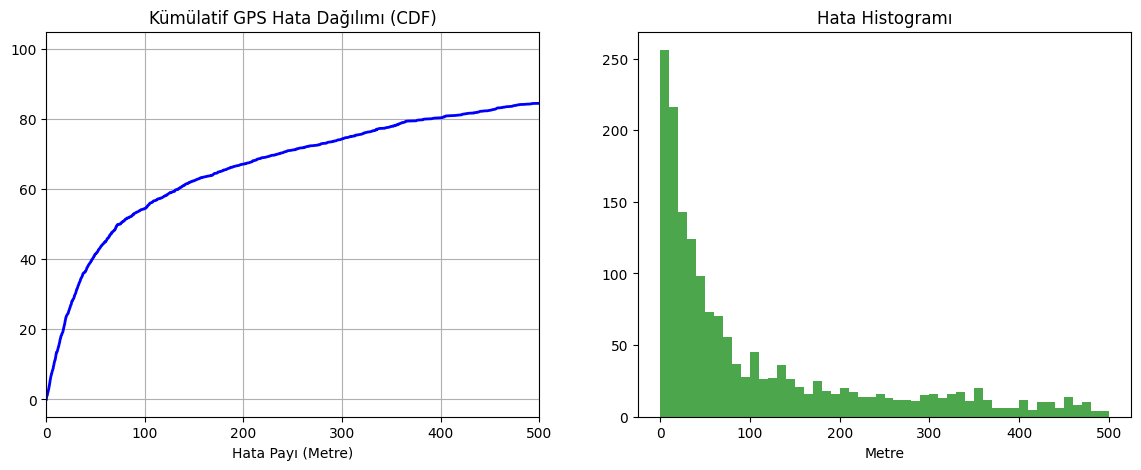

In [ ]:
# ============================================================
# Hücre 7: Değerlendirme & Metrikler (Recall@K ve Spatial Voting)
# ============================================================
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    p1, p2, dp, dl = map(math.radians, [lat1, lat2, lat2-lat1, lon2-lon1])
    a = math.sin(dp/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dl/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

qry_emb = query_embeddings.copy().astype(np.float32)
faiss.normalize_L2(qry_emb)
dists_all, idxs_all = faiss_index.search(qry_emb, TOP_K)

# Metrikleri Hesaplama Değişkenleri
errors_single = []
errors_spatial =[]
correct_street = 0

for i, q_row in df_query.iterrows():
    q_lat, q_lon = q_row["lat"], q_row["lon"]

    # Single-Image Top 1 Hata
    best_match = db_meta[idxs_all[i, 0]]
    errors_single.append(haversine(q_lat, q_lon, best_match["lat"], best_match["lon"]))

    # Spatial Voting (İlk 5 Sonucun Ağırlıklı Ortalaması)
    top_5 = [db_meta[idxs_all[i, k]] for k in range(5)]
    w = np.array([dists_all[i, k] for k in range(5)])
    w = np.maximum(w, 0); w /= (w.sum() + 1e-9)
    pred_lat = sum(m["lat"] * wi for m, wi in zip(top_5, w))
    pred_lon = sum(m["lon"] * wi for m, wi in zip(top_5, w))

    errors_spatial.append(haversine(q_lat, q_lon, pred_lat, pred_lon))
    if best_match["street"] == q_row["street"]: correct_street += 1

errors_single = np.array(errors_single)
errors_spatial = np.array(errors_spatial)

print(f"\n{'='*50}\n🏆 VPR SONUÇLARI (GÖRÜLMEMİŞ MAHALLELER)\n{'='*50}")
print(f"   Sokak İsmi Doğruluğu : {correct_street/len(df_query)*100:.2f}%")
print(f"\n📈 GPS HATA ÖZETİ (Spatial Voting):")
print(f"   Ortanca (Median) : {np.median(errors_spatial):.1f} metre")
print(f"   Ortalama (Mean)  : {errors_spatial.mean():.1f} metre")

print(f"\n📏 GPS Doğruluğu (Threshold Bazlı):")
for t in[25, 50, 100, 500]:
    acc = (errors_spatial <= t).mean() * 100
    print(f"   < {t:<3}m: {acc:>6.2f}%")

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sd = np.sort(errors_spatial)
cdf = np.arange(1, len(sd)+1) / len(sd) * 100
axes[0].plot(sd, cdf, lw=2, color="blue")
axes[0].set_xlim(0, 500); axes[0].grid(True)
axes[0].set_title("Kümülatif GPS Hata Dağılımı (CDF)"); axes[0].set_xlabel("Hata Payı (Metre)")

axes[1].hist(errors_spatial, bins=50, range=(0,500), color="green", alpha=0.7)
axes[1].set_title("Hata Histogramı"); axes[1].set_xlabel("Metre");
plt.show()

In [ ]:
# ============================================================
# Hücre 8: Harita Üzerinde Görselleştirme (Demo)
# ============================================================
demo_idx = random.sample(range(len(df_query)), min(10, len(df_query)))
m = folium.Map(location=[df_query["lat"].mean(), df_query["lon"].mean()], zoom_start=15)

for idx in demo_idx:
    q_row = df_query.iloc[idx]
    best_match = db_meta[idxs_all[idx, 0]]
    dist = haversine(q_row["lat"], q_row["lon"], best_match["lat"], best_match["lon"])

    # Gerçek Nokta (Mavi)
    folium.Marker([q_row["lat"], q_row["lon"]],
                  popup=f"SORGU<br>{q_row['street']}", icon=folium.Icon(color="blue")).add_to(m)
    # Tahmin Noktası (Kırmızı)
    folium.Marker([best_match["lat"], best_match["lon"]],
                  popup=f"TAHMİN<br>{best_match['street']}<br>Hata: {dist:.1f}m",
                  icon=folium.Icon(color="red", icon="flag")).add_to(m)
    folium.PolyLine([[q_row["lat"], q_row["lon"]], [best_match["lat"], best_match["lon"]]],
                    color="red" if dist>100 else "green", weight=2, dash_array="5").add_to(m)

m.save(os.path.join(OUTPUT_DIR, "vpr_final_map.html"))
m


📤 Dışarıdan bir Kırşehir fotoğrafı yükleyin (Test İçin):


Saving Screenshot 2026-03-18 154814.png to Screenshot 2026-03-18 154814.png


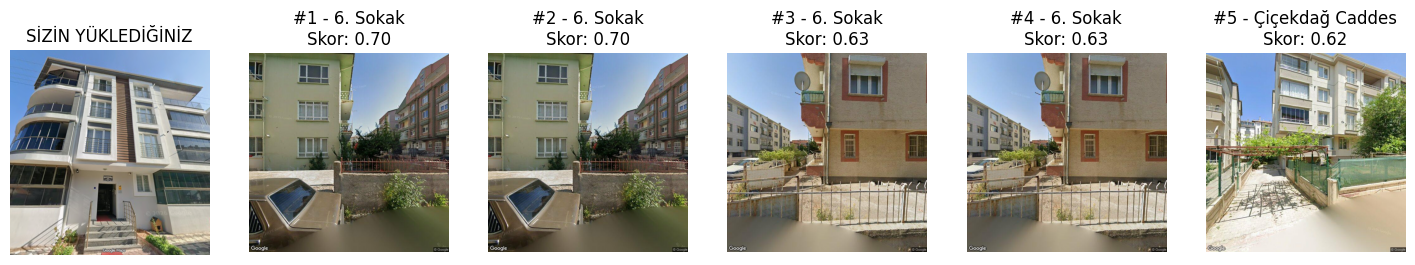

In [ ]:
# ============================================================
# Hücre 9: Dışarıdan Yükleme ile Test
# ============================================================
from google.colab import files

print("\n📤 Dışarıdan bir Kırşehir fotoğrafı yükleyin (Test İçin):")
uploaded = files.upload()

if uploaded:
    filename = list(uploaded.keys())[0]
    img = Image.open(filename).convert("RGB")

    model.eval()
    with torch.no_grad():
        emb = model(eval_transform(img).unsqueeze(0).to(DEVICE)).cpu().numpy().astype(np.float32)

    faiss.normalize_L2(emb)
    dists, idxs = faiss_index.search(emb, 5)

    fig, axes = plt.subplots(1, 6, figsize=(18, 4))
    axes[0].imshow(img); axes[0].set_title("SİZİN YÜKLEDİĞİNİZ"); axes[0].axis("off")

    for i in range(5):
        match = db_meta[idxs[0][i]]
        m_img = Image.open(match["filepath"])
        axes[i+1].imshow(m_img)
        axes[i+1].set_title(f"#{i+1} - {match['street'][:15]}\nSkor: {dists[0][i]:.2f}")
        axes[i+1].axis("off")
    plt.show()